# Phase 9 — Seasonality & Trend Analysis (Use Case 3)

**คำถามธุรกิจ:** ยอดขายที่ผันผวนของแต่ละหมวดหมู่สินค้า มาจากฤดูกาล/แนวโน้มมากแค่ไหน เทียบกับปัจจัยอื่น และแตกต่างกันไปตามหมวดหมู่หรือไม่?

**วิธีที่ใช้:** STL decomposition (Seasonal-Trend decomposition using LOESS) — แยกอนุกรมเวลาของยอดขายรวมแต่ละหมวดหมู่ (รวมทุก SKU/channel/region ในหมวดนั้น) ออกเป็น 3 ส่วน:
- **Trend** — แนวโน้มระยะยาว
- **Seasonal** — รูปแบบที่เกิดซ้ำทุกปี (period = 52 สัปดาห์)
- **Residual** — สิ่งที่เหลือหลังหักสองส่วนแรกออก (เช่น โปรโมชัน, เหตุการณ์เฉพาะกิจ, noise)

ใช้ `robust=True` เพื่อลดผลกระทบจากค่าผิดปกติ (outlier) ที่อาจเกิดจากสัปดาห์ที่มีโปรโมชันหนักผิดปกติ


In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

pd.set_option('display.width', 160)

df = pd.read_csv('../data/processed/weekly_features.csv', parse_dates=['week'])
cat_weekly = df.groupby(['category', 'week']).units_sold.sum().reset_index()
categories = sorted(cat_weekly.category.unique())
print('categories:', categories)


categories: ['Juice', 'Milk', 'ReadyMeal', 'SnackBar', 'Yogurt']


## 1. รัน STL แยกทีละหมวดหมู่


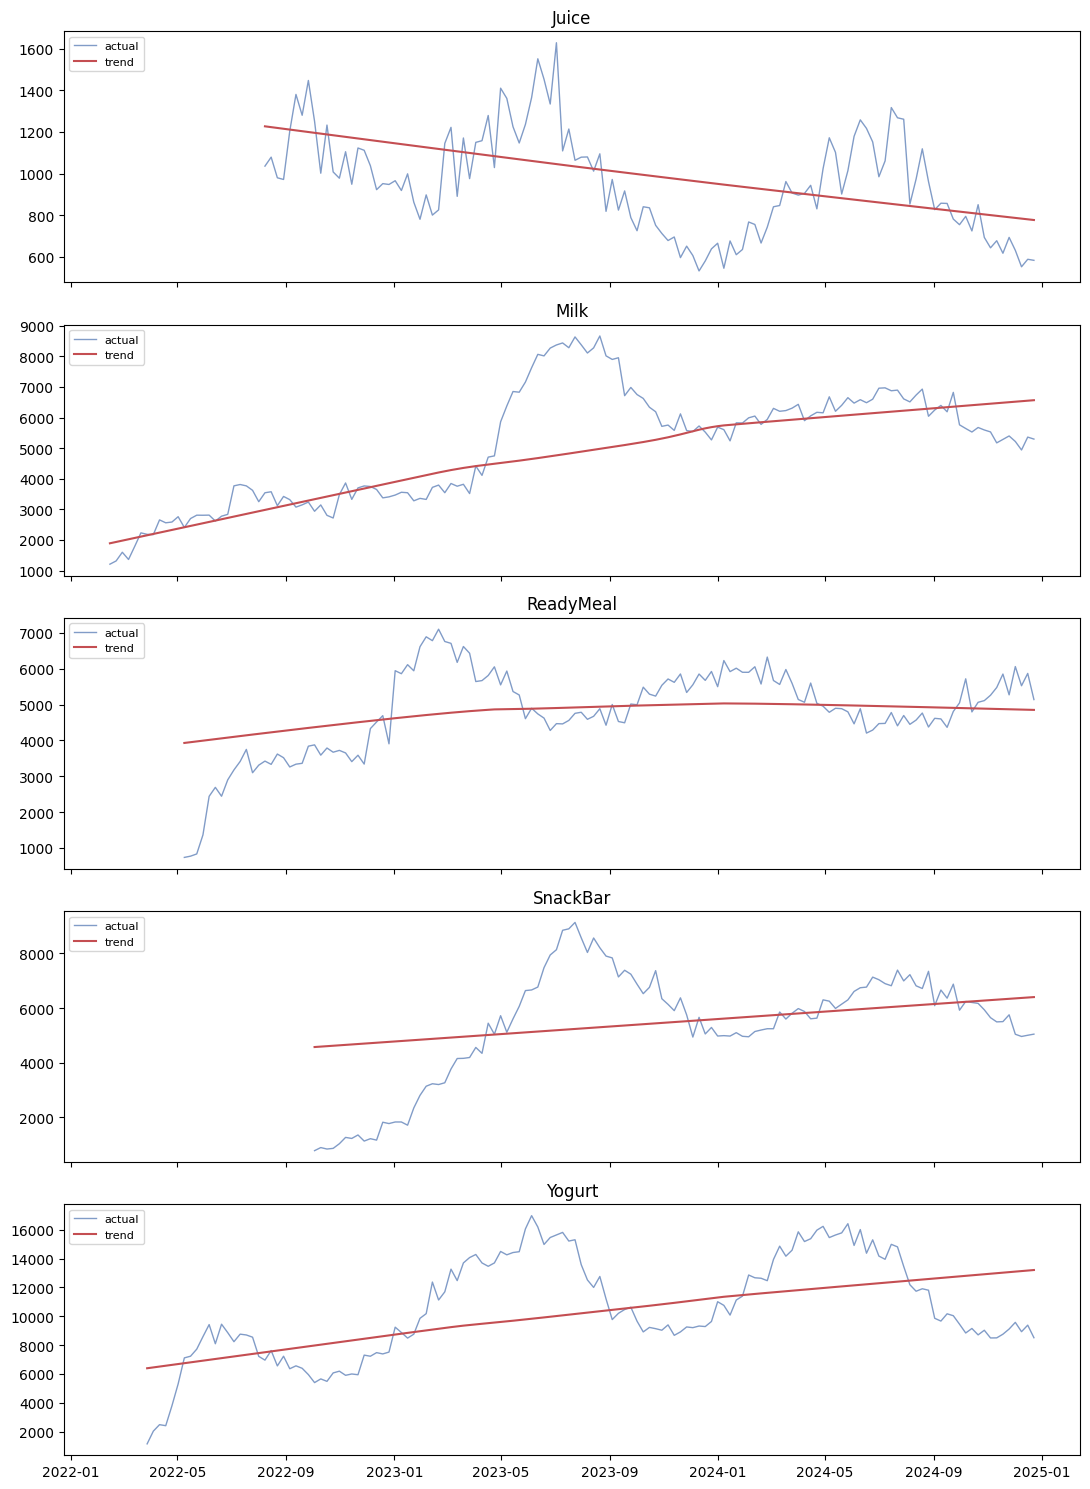

In [2]:
stl_results = {}
for cat in categories:
    s = cat_weekly[cat_weekly.category == cat].set_index('week')['units_sold'].asfreq('W-MON')
    s = s.interpolate()  # เติมสัปดาห์ที่ขาดหาย (ถ้ามี) ด้วยการ interpolate เชิงเส้น ก่อนป้อนเข้า STL ซึ่งต้องการอนุกรมต่อเนื่อง
    stl_results[cat] = STL(s, period=52, robust=True).fit()

fig, axes = plt.subplots(len(categories), 1, figsize=(11, 3 * len(categories)), sharex=True)
for ax, cat in zip(axes, categories):
    s = cat_weekly[cat_weekly.category == cat].set_index('week')['units_sold']
    ax.plot(s.index, s.values, color='#4C72B0', linewidth=1, alpha=0.7, label='actual')
    ax.plot(stl_results[cat].trend.index, stl_results[cat].trend.values, color='#C44E52', linewidth=1.5, label='trend')
    ax.set_title(cat)
    ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/figures/phase9_stl_trend_overview.png', dpi=120)
plt.show()


## 2. สัดส่วนความผันผวนที่อธิบายได้ (Variance Share)

คำนวณสัดส่วนความแปรปรวน (variance) ของแต่ละส่วนประกอบเทียบกับความแปรปรวนรวมของอนุกรมต้นฉบับ — ตัวเลขนี้บอกว่า **ฤดูกาลอธิบายความผันผวนของยอดขายได้กี่ %** เทียบกับแนวโน้มระยะยาวและส่วนที่เหลือ (หมายเหตุ: ผลรวม 3 สัดส่วนไม่จำเป็นต้องเท่ากับ 100% เป๊ะ เพราะ trend/seasonal/residual ไม่ได้เป็นอิสระต่อกันทางสถิติเสมอไป)


In [3]:
rows = []
for cat in categories:
    res = stl_results[cat]
    var_total = np.var(res.observed)
    rows.append({
        'category': cat,
        'n_weeks': len(res.observed),
        'seasonal_share': np.var(res.seasonal) / var_total,
        'trend_share': np.var(res.trend) / var_total,
        'resid_share': np.var(res.resid) / var_total,
    })

variance_shares = pd.DataFrame(rows).sort_values('seasonal_share', ascending=False).reset_index(drop=True)
variance_shares.round(3)


,category,n_weeks,seasonal_share,trend_share,resid_share
0,SnackBar,117,0.869,0.067,0.234
1,ReadyMeal,138,0.757,0.066,0.153
2,Juice,125,0.726,0.298,0.116
3,Yogurt,144,0.534,0.324,0.211
4,Milk,150,0.083,0.575,0.284


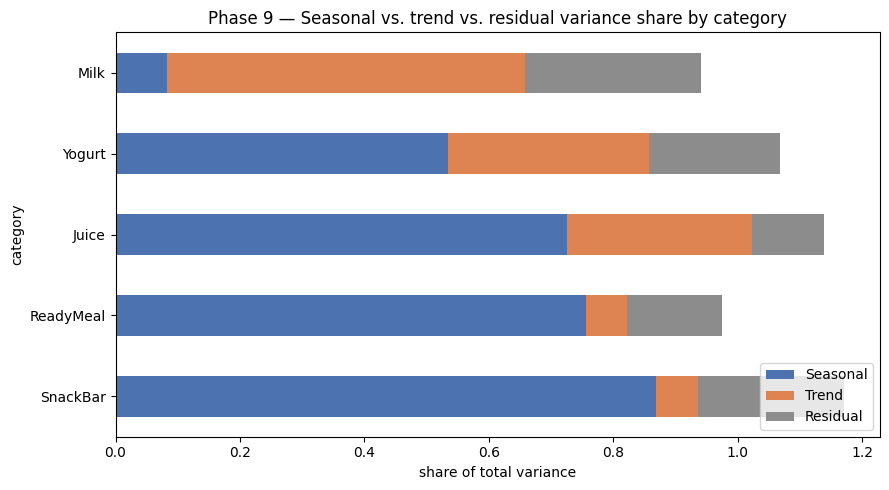

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = variance_shares.set_index('category')[['seasonal_share', 'trend_share', 'resid_share']]
plot_df.plot(kind='barh', stacked=True, ax=ax, color=['#4C72B0', '#DD8452', '#8C8C8C'])
ax.set_xlabel('share of total variance')
ax.set_title('Phase 9 — Seasonal vs. trend vs. residual variance share by category')
ax.legend(['Seasonal', 'Trend', 'Residual'], loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/phase9_variance_shares.png', dpi=120)
plt.show()


## 3. ข้อสังเกตรายหมวดหมู่

- **SnackBar และ ReadyMeal** — สัดส่วนฤดูกาลสูงมาก (~76-87% ของความผันผวน) แปลว่ายอดขายของสองหมวดนี้ผันผวนตามช่วงเวลาของปีเป็นหลัก (เช่น เทศกาล, ฤดูกาลบริโภค) มากกว่าจะเป็นแนวโน้มระยะยาวหรือปัจจัยสุ่ม
- **Juice** — สัดส่วนฤดูกาลสูงเช่นกัน (~73%) แต่ต้องตีความอย่างระวังเพราะมีแค่ 1 SKU (JU-021) เป็นตัวแทนทั้งหมวด และมีประวัติสั้นกว่าหมวดอื่น (125 สัปดาห์ เทียบกับ 150 สัปดาห์ของหมวดอื่น)
- **Yogurt** — สัดส่วนฤดูกาล/แนวโน้มใกล้เคียงกัน (53%/32%) เป็นหมวดที่มีทั้งฤดูกาลชัดเจนและแนวโน้มเติบโตต่อเนื่อง (สอดคล้องกับเป็นหมวดที่มี SKU มากที่สุด 11 ตัว ทยอยเปิดตัวเพิ่มเรื่อยๆ)
- **Milk** — แตกต่างจากหมวดอื่นชัดเจน: **แนวโน้มครอบงำ** (57.5%) มากกว่าฤดูกาล (8.3%) — ยอดขายนมผันผวนตามการเติบโตของธุรกิจ/จำนวน SKU ที่ active มากกว่าจะเป็นเรื่องฤดูกาล ซึ่งสมเหตุสมผลเพราะนมเป็นสินค้าที่ความต้องการค่อนข้างสม่ำเสมอตลอดปี ไม่ผูกกับเทศกาลมากเท่าขนม/อาหารพร้อมทาน

## 4. สรุป Phase 9

การผันผวนของยอดขาย**ไม่ได้มาจากฤดูกาลในสัดส่วนเท่ากันทุกหมวดหมู่** — SnackBar/ReadyMeal/Juice ขับเคลื่อนด้วยฤดูกาลเป็นหลัก ในขณะที่ Milk ขับเคลื่อนด้วยแนวโน้มระยะยาวเป็นหลัก ข้อค้นพบนี้มีนัยเชิงธุรกิจ: การวางแผนสต๊อกสำหรับ SnackBar/ReadyMeal ควรให้น้ำหนักกับปฏิทินฤดูกาลมากกว่า Milk ที่ควรเน้นติดตามแนวโน้มการเติบโตของธุรกิจแทน
